# 07. Walk-Forward Strategy & Model Comparison

**Goal:** Build and test automated walk-forward trading strategies, moving beyond in-sample R² to the metrics that actually matter for a tradable portfolio: **Information Coefficient (IC)** and **Long/Short Alpha**.

**Context:** In §3.1, we built a backward-looking PM assistant. Now we build a **forward-looking, automated trading engine** using the only true test of predictive power: walk-forward testing.

**New "Ground Truth" — Why We No Longer Care About R²:**
- R² measures magnitude of errors. A heavily regularized model with "dull" predictions can have terrible R² but excellent *rank quality*.
- A PM running a long/short portfolio cares *which stocks* are in the top and bottom deciles, not whether the model predicted 5% or 7%.
- We grade on **Rank IC** (Spearman correlation between predictions and actuals) and **Long/Short Alpha** (the spread between long and short portfolios using actual unclipped returns).

**Structure:**
1. **Part 1:** Basic TV-style walk-forward with R²-tuned XGBoost
2. **Part 2:** Optuna IC-tuned model with advanced alpha target + XGBRanker
3. **Part 3:** Blended Model (BayesianRidge + XGBoost adaptive) final comparison

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))

from src.utils.logger import setup_logger
from src.utils.config_loader import load_config
from src.backtest.walk_forward import (
    run_walk_forward_tv_style,
    print_performance_metrics,
    calculate_performance_metrics,
    run_master_strategy,
    AdaptiveBlendedModel,
    coerce_yyyymm_to_month_end,
    build_market_fwdret_series,
    add_rolling_market_beta,
    default_monotonic_constraints,
    quant_preprocess_features,
)
from src.backtest.metrics import sharpe_ratio, max_drawdown, information_coefficient

logger = setup_logger("07_walk_forward")
config = load_config()

pd.set_option("display.float_format", "{:,.4f}".format)
np.random.seed(42)

### Data Preparation

The walk-forward engine needs `Date` and `Ticker` as **regular columns** (not index levels) because it filters by date slices. We also need `FwdRetOrig` (unclipped actual returns) for realistic P&L computation — the model trains on clipped `FwdRet` but we measure portfolio performance on raw returns.

In [2]:
# Load processed data
data_path = config['paths']['processed_data']
df = pd.read_parquet(data_path)
logger.info(f"Data Loaded. Shape: {df.shape}")

# Reset MultiIndex to get Date and Ticker as columns
df = df.reset_index()

# Verify required columns
date_col = config['data']['date_col']
ticker_col = config['data']['ticker_col']
print(f"Date column: '{date_col}', Ticker column: '{ticker_col}'")
print(f"Columns: {df.columns.tolist()[:10]}...")

# Verify FwdRetOrig is present
assert 'FwdRetOrig' in df.columns, "FwdRetOrig missing! Re-run Notebook 02 with the save fix."
print(f"\nFwdRetOrig present: {df['FwdRetOrig'].notna().sum():,} non-null values")
print(f"Full dataset shape: {df.shape}")

2026-03-07 18:16:27,519 - INFO - Data Loaded. Shape: (93829, 94)
Date column: 'Date', Ticker column: 'Ticker'
Columns: ['Date', 'Ticker', 'Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr']...

FwdRetOrig present: 93,829 non-null values
Full dataset shape: (93829, 96)


### Feature Definition

We define the feature columns used throughout the walk-forward tests. The consolidated notebook uses `final_numerical_features` (10 risk factors + 4 kept extras) for the TV-style strategy, without GICS dummies — this keeps the feature set simple and avoids overfitting to sector-specific patterns in a walk-forward context.

In [3]:
# Core risk factors + kept extras from Section 1.2-1.3
rsk_cols = config['data']['risk_factors']
keep_extra = config['data']['keep_extra']

final_numerical_features = rsk_cols + keep_extra
features_tv_xgb = list(dict.fromkeys(final_numerical_features))  # deduplicate

print(f"Number of features for TV-style strategy: {len(features_tv_xgb)}")
print(f"Features: {features_tv_xgb}")

Number of features for TV-style strategy: 14
Features: ['Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr', 'Dvd Yld', 'Earn Var', 'BEst P/S BF12M', 'BEst P/B BF12M', 'BEst P/E BF12M', 'Beta:Y-1']


---

## Part 1: Basic TV-Style Walk-Forward (R²-Tuned XGBoost)

This is the simplest walk-forward strategy:
- **Model:** XGBoost champion with Optuna-tuned parameters from §2.2
- **Window:** 10-period rolling lookback
- **Portfolio:** Long top 15%, short bottom 15% (minimum 30 names per side)
- **P&L:** Measured on **unclipped** returns (`FwdRetOrig`)
- **Metric:** Rank IC (Spearman) + Long-Short Alpha

In [4]:
from xgboost import XGBRegressor

# Load champion model params from config
params = config['model']['params']
xgb_champion = XGBRegressor(
    n_estimators=params['n_estimators'],
    max_depth=params['max_depth'],
    learning_rate=params['learning_rate'],
    subsample=params['subsample'],
    colsample_bytree=params['colsample_bytree'],
    reg_lambda=params['reg_lambda'],
    objective="reg:squarederror",
    tree_method="hist",
    random_state=params.get('random_state', 42),
    n_jobs=params.get('n_jobs', -1)
)

print("XGBoost Champion parameters:")
print(xgb_champion.get_params())

XGBoost Champion parameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7615464432458687, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.023324877778608765, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 593, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': 5.01325529529293, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7538740745529875, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


#### Run the Walk-Forward Backtest

In [5]:
results_tv_xgb, stats_tv_xgb = run_walk_forward_tv_style(
    df=df,
    feature_cols=features_tv_xgb,
    model=xgb_champion,
    window=10,
    top_bottom_frac=0.15,
    min_names=30,
    window_type="rolling",
    verbose=False
)

print(f"Walk-forward periods: {len(results_tv_xgb)}")

Walk-forward periods: 97


#### Performance Metrics

In [6]:
print_performance_metrics(results_tv_xgb, label="TV_XGB_10Q_Decile")

STRATEGY PERFORMANCE METRICS: TV_XGB_10Q_Decile
Mean Rank IC: 0.0005
IC Hit Rate: 52.58%

Long Portfolio:
  Cumulative Return: +3.9219 (+392.19%)
  Mean Quarterly Return: +0.0404
  Volatility (Quarterly): 0.1227
  Information Ratio (Annualized): 0.6590

Short Portfolio:
  Cumulative Return: +4.1234 (+412.34%)
  Mean Quarterly Return: +0.0425
  Volatility (Quarterly): 0.1344
  Information Ratio (Annualized): 0.6327

Benchmark (Market Average):
  Cumulative Return: +3.4725 (+347.25%)
  Mean Quarterly Return: +0.0358

Excess Returns vs Benchmark:
  Long Portfolio Excess: +0.4494 (+44.94%)
  Short Portfolio Excess: -0.6509 (-65.09%)


In [7]:
# Summary table
summary_table = pd.DataFrame(
    {
        "Mean IC": [stats_tv_xgb["mean_ic"]],
        "IC Hit Rate": [stats_tv_xgb["ic_hit_rate"]],
        "Cumulative Alpha": [stats_tv_xgb["cumulative_alpha"]],
        "Sharpe Ratio": [stats_tv_xgb["sharpe_ratio"]],
        "Max Drawdown": [stats_tv_xgb["max_drawdown"]],
    },
    index=["TV_XGB_10Q_Decile"]
)

print("Summary performance table:")
summary_table

Summary performance table:


,Mean IC,IC Hit Rate,Cumulative Alpha,Sharpe Ratio,Max Drawdown
TV_XGB_10Q_Decile,0.0005,0.5258,-0.2015,-0.0552,-0.5068


#### Annual Breakdown

In [9]:
# Annual average metrics by calendar year
annual_results = results_tv_xgb.copy()
annual_results["year"] = annual_results.index.astype(str).str[:4].astype(int)

cols = ["rank_ic", "long_return", "short_return", "benchmark_return", "long_short_alpha"]
annual_avg = annual_results.groupby("year")[cols].mean().sort_index()

print("Annual average metrics (by calendar year):")
print(annual_avg)

Annual average metrics (by calendar year):
      rank_ic  long_return  short_return  benchmark_return  long_short_alpha
year                                                                        
2001  -0.3160       0.1377        0.4196            0.1791           -0.2819
2002  -0.0673      -0.0606       -0.0147           -0.0217           -0.0459
2003  -0.0073       0.1272        0.1417            0.1060           -0.0145
2004   0.0013       0.0447        0.0476            0.0502           -0.0029
2005   0.0199       0.0298        0.0299            0.0267           -0.0001
2006  -0.0050       0.0418        0.0363            0.0419            0.0054
2007   0.1007       0.0253       -0.0271            0.0121            0.0524
2008  -0.0552      -0.1507       -0.0843           -0.1030           -0.0664
2009  -0.0627       0.1207        0.1470            0.1102           -0.0263
2010   0.0887       0.0990        0.0527            0.0643            0.0463
2011  -0.0436      -0.0059       

#### Cumulative P&L Charts

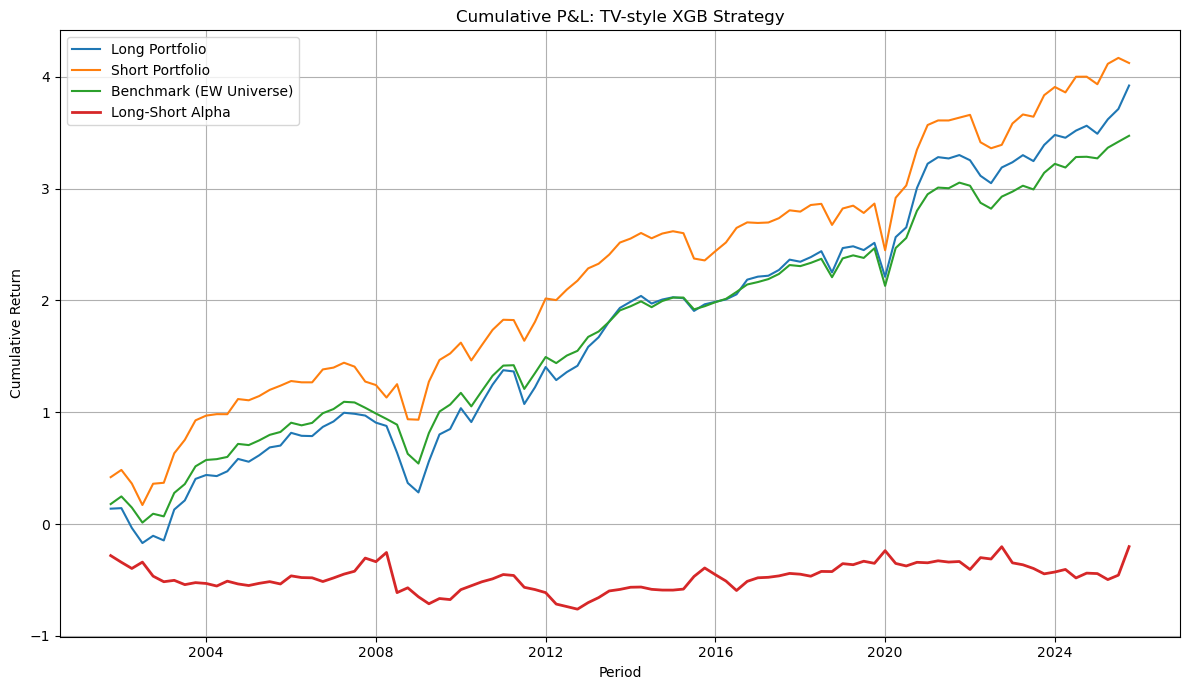

In [10]:
# Cumulative long, short, benchmark, and alpha
cum_long = results_tv_xgb['long_return'].cumsum()
cum_short = results_tv_xgb['short_return'].cumsum()
cum_bench = results_tv_xgb['benchmark_return'].cumsum()
cum_ls = results_tv_xgb['long_short_alpha'].cumsum()

plt.figure(figsize=(12, 7))
plt.plot(cum_long.index, cum_long.values, label="Long Portfolio")
plt.plot(cum_short.index, cum_short.values, label="Short Portfolio")
plt.plot(cum_bench.index, cum_bench.values, label="Benchmark (EW Universe)")
plt.plot(cum_ls.index, cum_ls.values, label="Long-Short Alpha", linewidth=2)

plt.title("Cumulative P&L: TV-style XGB Strategy")
plt.xlabel("Period")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

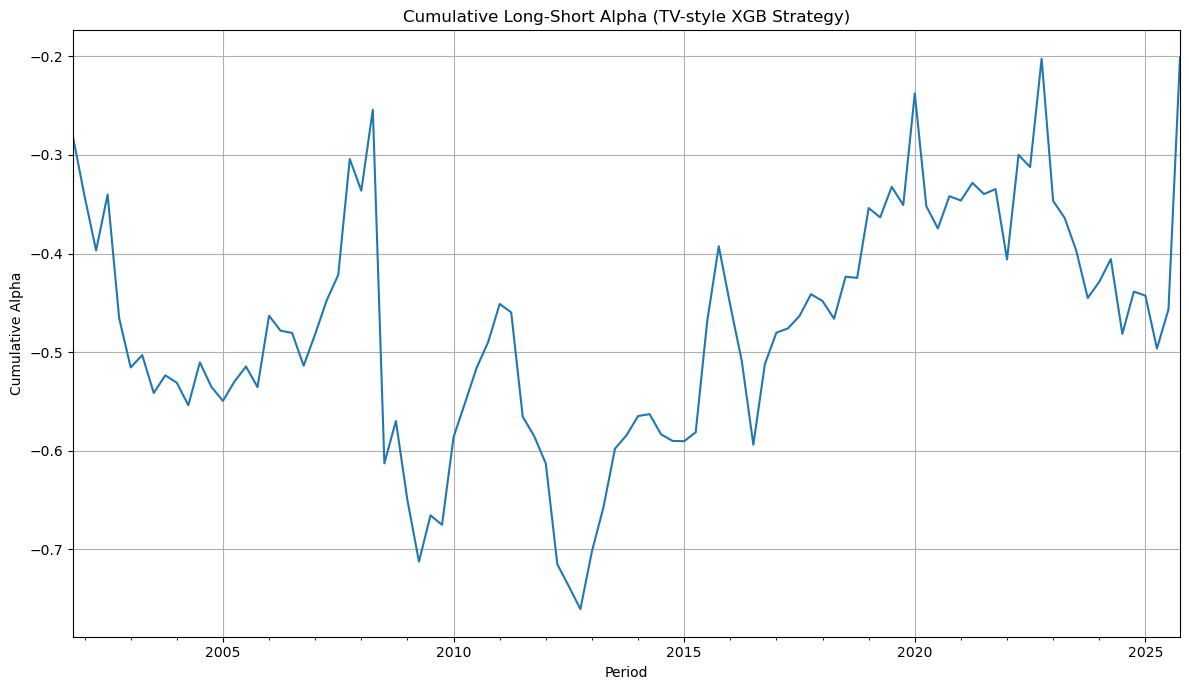

In [11]:
# Cumulative long-short alpha alone
plt.figure(figsize=(12, 7))
results_tv_xgb['long_short_alpha'].cumsum().plot(grid=True)
plt.title("Cumulative Long-Short Alpha (TV-style XGB Strategy)")
plt.xlabel("Period")
plt.ylabel("Cumulative Alpha")
plt.tight_layout()
plt.show()

**Part 1 Observations:**

The basic TV-style walk-forward using the R²-tuned XGBoost reveals a **critical lesson: in-sample R² does not translate to walk-forward alpha.**

**The headline numbers are sobering:**
- **Mean Rank IC = 0.0005** — essentially zero. The model's predictions have no meaningful rank correlation with actual returns out-of-sample.
- **IC Hit Rate = 52.6%** — barely above a coin flip.
- **Cumulative Long-Short Alpha = −20.2%** — the strategy *lost money* over 25 years.
- **Sharpe Ratio = −0.06** — negative risk-adjusted return.
- **Max Drawdown = −50.7%** — at its worst, the strategy gave back half of any gains.

**What the P&L chart reveals:**
- Both the Long Portfolio (+392%) and Short Portfolio (+412%) rise over 25 years — but the Short Portfolio actually **outperforms the Long Portfolio** by ~20 percentage points. This means the model's "worst" stocks did *better* than its "best" stocks, exactly the opposite of what a working strategy should produce.
- The Benchmark (equal-weight universe, +347%) sits between the two, confirming that both long and short portfolios captured broad market beta but the ranking signal added no value.
- The Long-Short Alpha line (dark red) stays **negative for the entire 25-year period**, never crossing zero. It starts around −0.28 (2001), deteriorates to −0.75 during the GFC and 2012–2013, partially recovers to −0.20 by 2023, then dips again.

**The annual breakdown tells the story in more detail:**
- **Catastrophic start: 2001 (alpha = −28.2%)** — the model's first full year produced a massive negative alpha. The short portfolio returned +42% while the long returned only +14%, suggesting the model systematically picked the wrong side during the dot-com recovery.
- **GFC pain: 2008 (alpha = −6.6%)** — in the crisis, the long portfolio fell −15% while the short fell only −8%. The model's "best" stocks were hit harder than its "worst."
- **Positive stretches exist but are modest:** 2007 (+5.2%), 2010 (+4.6%), 2013 (+4.4%), 2015 (+4.9%), 2022 (+3.3%), 2025 (+5.9%). These are real but insufficient to offset the bad years.
- **Most years are near-zero:** 2004 (−0.3%), 2005 (−0.01%), 2006 (+0.5%), 2014 (−0.1%), 2018 (+0.4%), 2024 (+0.2%). The model simply has no edge in normal markets.
- **Recent trouble: 2023 (alpha = −6.1%)** — the model picked the wrong side of the regional banking crisis and AI rally.

**Why did the R²-tuned model fail in walk-forward?**

This result is entirely consistent with what we warned about at the start of this notebook: **R² measures the magnitude of prediction errors, not rank quality.** The Optuna-tuned XGBoost from §2.2 was optimized to minimize squared error on 2023+ data. In walk-forward testing across 25 years of diverse market regimes, that optimization doesn't help — and may actively hurt by overfitting to a specific regime's factor relationships.

> **Key takeaway:** A model with in-sample R² of ~0.10 and in-sample IC of ~0.59 (Notebook 06) produces near-zero IC and negative alpha out-of-sample. This is the fundamental reason we need Parts 2 and 3: optimizing directly for rank quality (IC) and/or blending with a more stable model.

---

## Part 2: Experiments with IC-Tuned XGBoost

The R²-tuned model from §2.2 was optimized for prediction accuracy. But in a long/short context, **rank quality matters more than magnitude accuracy**. We now use Optuna to tune XGBoost specifically for **Mean Rank IC** from the walk-forward backtest.

### Optuna IC Optimization

We use the first 70% of dates for tuning (no test-period contamination) and maximize Mean Rank IC directly.

In [12]:
import optuna

# Use first 70% of dates for tuning
all_dates = sorted(df["Date"].unique())
split_idx = int(0.7 * len(all_dates))
tune_dates = all_dates[:split_idx]

df_tune = df[df["Date"].isin(tune_dates)].copy()
print(f"Tuning on {len(tune_dates)} periods out of {len(all_dates)} total.")

Tuning on 74 periods out of 107 total.


In [14]:
def objective_ic(trial):
    """Optuna objective: maximize Mean Rank IC from walk-forward."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 900),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 100.0, log=True),
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBRegressor(**params)

    results_df, stats = run_walk_forward_tv_style(
        df=df_tune,
        feature_cols=features_tv_xgb,
        model=model,
        window=12,
        top_bottom_frac=0.10,
        min_names=30,
        window_type="rolling",
        verbose=False,
    )

    score = stats["mean_ic"]
    if np.isnan(score):
        return -1e9

    return score

study_ic = optuna.create_study(
    direction="maximize",
    study_name="xgb_tune_mean_ic",
)

study_ic.optimize(objective_ic, n_trials=30, show_progress_bar=True)

print(f"\nBest Mean IC: {study_ic.best_value:.4f}")
print("Best parameters:")
for k, v in study_ic.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-08 03:52:28,134] A new study created in memory with name: xgb_tune_mean_ic


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-08 03:53:06,320] Trial 0 finished with value: 5.828250647754069e-05 and parameters: {'n_estimators': 206, 'max_depth': 7, 'learning_rate': 0.047996908100590645, 'subsample': 0.8350784717033555, 'colsample_bytree': 0.7645990617279063, 'reg_lambda': 4.537948695354369}. Best is trial 0 with value: 5.828250647754069e-05.
[I 2026-03-08 03:53:30,827] Trial 1 finished with value: -0.0018352592522748964 and parameters: {'n_estimators': 487, 'max_depth': 3, 'learning_rate': 0.007210236796784698, 'subsample': 0.9939986382498976, 'colsample_bytree': 0.655954558754569, 'reg_lambda': 15.368544139598884}. Best is trial 0 with value: 5.828250647754069e-05.
[I 2026-03-08 03:54:12,841] Trial 2 finished with value: 0.005922876824526556 and parameters: {'n_estimators': 537, 'max_depth': 5, 'learning_rate': 0.014878016430883314, 'subsample': 0.9238789790873383, 'colsample_bytree': 0.6082030114659082, 'reg_lambda': 26.67267550021234}. Best is trial 2 with value: 0.005922876824526556.
[I 2026-03-

### Advanced Master Strategy: Alpha Target + XGBRanker

The basic strategy trains on clipped `FwdRet` using `reg:squarederror`. The advanced version makes three key improvements:

1. **Beta-neutral alpha target:** Instead of predicting raw returns, we predict `Alpha = FwdRet - Beta × Market_FwdRet`, which removes the market component.
2. **XGBRanker with `rank:pairwise` objective:** Instead of minimizing squared error, we directly optimize the ranking quality — which is exactly what IC measures.
3. **Monotonic constraints:** We force the model to respect economic logic (e.g., higher Profitability should help, higher Leverage should hurt).
4. **Cross-sectional feature ranking:** Features are ranked within each date to [0, 1], making the model robust to regime shifts in absolute factor levels.

**Note on yfinance:** The market beta calculation uses S&P 500 data via `yfinance`. If internet is unavailable, it falls back to the universe mean return as a market proxy.

In [15]:
# Prepare data with market beta
df_q = df.copy()

# Parse dates for the advanced strategy
df_q["Date"] = coerce_yyyymm_to_month_end(df_q["Date"])
df_q = df_q.dropna(subset=["Date"])

# Build market forward return series
unique_dates = sorted(df_q["Date"].unique())
start_date = unique_dates[0] - pd.Timedelta(days=400)
end_date = unique_dates[-1] + pd.Timedelta(days=30)

# Fallback: cross-sectional mean forward return by date
fallback_mkt = df_q.groupby("Date")["FwdRet"].mean()

# Try yfinance first, fall back to universe mean if unavailable
mkt_fwdret_by_date = build_market_fwdret_series(
    unique_dates=unique_dates,
    start_date=start_date,
    end_date=end_date,
    use_yfinance=True,          # Set to False if no internet
    fallback_universe_mean=fallback_mkt,
)

# Map market return to each row
df_q["Mkt_FwdRet"] = df_q["Date"].map(mkt_fwdret_by_date)

# Estimate rolling market beta (backward-looking, no lookahead)
if "MarketBeta" not in df_q.columns:
    print("MarketBeta missing -> estimating rolling beta with no lookahead...")
    df_q = add_rolling_market_beta(
        df_q,
        mkt_fwdret_by_date=mkt_fwdret_by_date,
        beta_window=12,
        min_obs=8,
        beta_clip=(-1.0, 3.0),
    )
else:
    df_q["MarketBeta"] = (
        pd.to_numeric(df_q["MarketBeta"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(1.0)
        .clip(-1.0, 3.0)
    )

print(f"df_q shape: {df_q.shape}")
print(f"MarketBeta stats: {df_q['MarketBeta'].describe()}")

MarketBeta missing -> estimating rolling beta with no lookahead...
df_q shape: (93829, 98)
MarketBeta stats: count   93,829.0000
mean         1.0809
std          0.7617
min         -1.0000
25%          0.6366
50%          1.0000
75%          1.4770
max          3.0000
Name: MarketBeta, dtype: float64


#### Run the Advanced Master Strategy

Using the IC-tuned parameters with the XGBRanker approach.

Running master strategy with 14 features...

Mean Rank IC:   0.0097
Mean Spread:    -0.0083
Hit Rate (>0):  52.87%


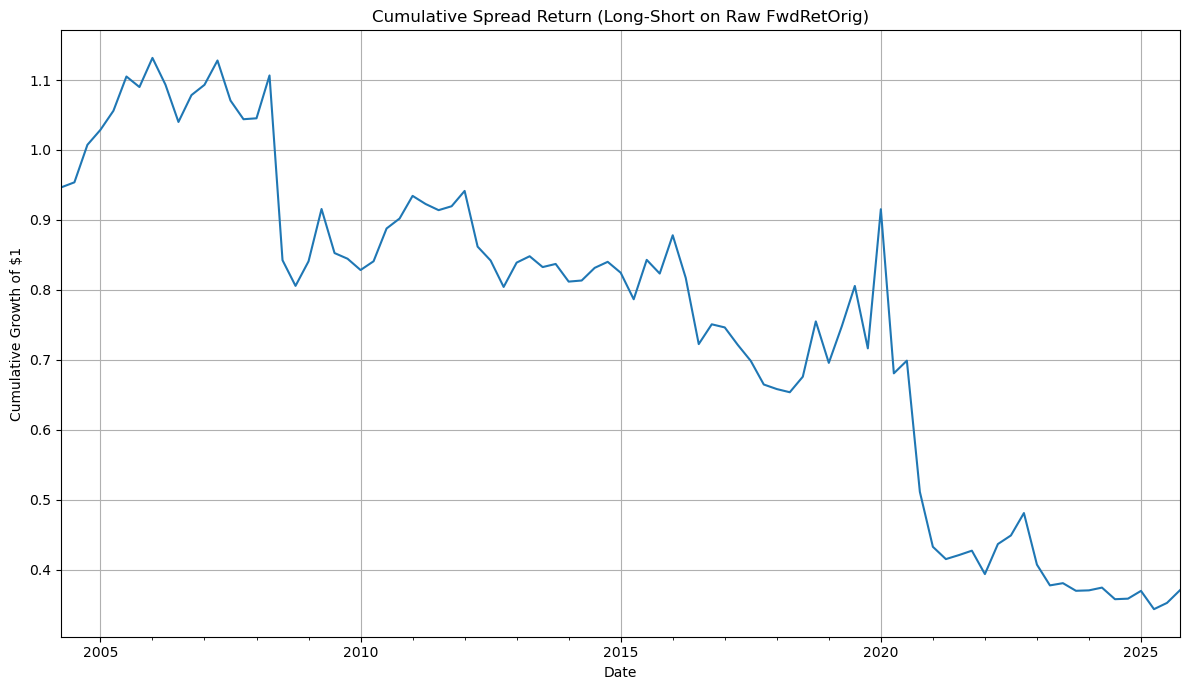

In [18]:
# Use IC-tuned params (update these after running Optuna above)
xgb_quant_params = dict(study_ic.best_params)
xgb_quant_params.update({
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": 42,
})

print(f"Running master strategy with {len(features_tv_xgb)} features...")

results_df_q = run_master_strategy(
    df=df_q,
    feature_cols=features_tv_xgb,
    xgb_params=xgb_quant_params,
    window=20,
    top_bottom_frac=0.10,
    min_test_names=50,
)

if results_df_q.empty:
    print("No results produced. Check window size and min_test_names.")
else:
    print(f"\nMean Rank IC:   {results_df_q['Rank_IC'].mean():.4f}")
    print(f"Mean Spread:    {results_df_q['Spread'].mean():.4f}")
    print(f"Hit Rate (>0):  {(results_df_q['Spread'] > 0).mean():.2%}")

    # Cumulative spread plot
    ax = (1 + results_df_q.set_index("Date")["Spread"]).cumprod().plot(
        title="Cumulative Spread Return (Long-Short on Raw FwdRetOrig)",
        figsize=(12, 7)
    )
    ax.set_ylabel("Cumulative Growth of $1")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

**Part 2 Observations:**

**Optuna IC Optimization:**

The IC-tuned Optuna study ran 30 trials on the first 70% of dates (74 periods), searching for the XGBoost configuration that maximizes Mean Rank IC from the walk-forward backtest.

- **Best Mean IC = 0.0102** — a meaningful improvement over Part 1's near-zero IC (0.0005), but still very low in absolute terms. For context, production quant strategies target IC > 0.05.
- The optimization trajectory shows gradual improvement: early trials bounced between negative and near-zero IC, with the best configurations converging in the later trials (22 and 29).
- **Winning parameters:** `n_estimators=790`, `max_depth=3`, `learning_rate=0.034`, `subsample=0.66`, `colsample_bytree=0.74`, `reg_lambda=44.5`
- Compared to the R²-tuned model from §2.2 (`max_depth=5`, `learning_rate=0.023`, `reg_lambda=5.0`), the IC-tuned model is **shallower** (depth 3 vs 5), uses a **higher learning rate** (0.034 vs 0.023), and has **much stronger L2 regularization** (lambda 44.5 vs 5.0). This makes sense: out-of-sample rank quality favors simpler, more regularized models that don't overfit to in-sample patterns.

**Advanced Master Strategy (XGBRanker + Alpha Target):**

The master strategy adds three layers of sophistication on top of the IC-tuned parameters: beta-neutral alpha target, `rank:pairwise` objective, monotonic constraints, and cross-sectional feature ranking.

- **Mean Rank IC = 0.0097** — essentially the same as the Optuna IC-tuned result (0.0102). The added complexity did not improve rank quality.
- **Mean Spread = −0.83%** — the strategy is *losing money* on average per period. The long portfolio underperforms the short portfolio.
- **Hit Rate = 52.9%** — barely above a coin flip, consistent with the near-zero IC.

**What the cumulative spread chart reveals:**
- The strategy starts with a brief period above $1.00 (2004–2008), peaking around **$1.13** in 2006–2007 — the only stretch where the ranking signal produced tradable alpha.
- The GFC (2008–2009) triggers a sharp drawdown to ~$0.83, erasing all gains.
- From 2009–2013, the strategy oscillates between $0.80 and $0.94 — sideways with no clear direction.
- Starting around **2015**, the decline accelerates: the curve falls steadily from ~$0.88 to ~$0.65 by 2018.
- A brief recovery to ~$0.91 around 2020 (likely COVID rebound dynamics) is immediately followed by the **most severe collapse** in the entire history: from $0.91 to **$0.35** by 2025.
- The strategy ends at roughly **$0.35–0.37** — meaning $1 invested at the start would have lost ~65% of its value over 20 years of walk-forward trading.

**Why did the advanced strategy also fail?**

Despite the sophistication — alpha target, ranking objective, monotonic constraints, feature ranking — the fundamental problem remains: **XGBoost's factor relationships are not stable across 25 years of market regimes.** The model learns patterns from the training window that don't persist into the test period.

Several specific dynamics are visible:
- The **pre-2008 period** had different factor premia (value worked, momentum worked differently). The model tuned on 2004–era data made reasonable bets.
- The **post-2015 collapse** coincides with the factor "crowding" era — when traditional quant factor strategies became increasingly crowded and many long-short factor portfolios suffered persistent drawdowns.
- The **2020–2025 accelerating decline** reflects the unprecedented concentration of returns in a handful of mega-cap tech/AI names that don't conform to traditional factor models. When NVDA, META, and a few others drive most of the market's return, a cross-sectional factor model that ranks 500+ stocks struggles to capture this.

> **Key takeaway:** Optimizing for IC and using advanced ranking techniques (XGBRanker, alpha target, monotonic constraints) produced marginally better IC (~0.01 vs ~0.00) but did not translate into positive trading alpha. The cumulative spread chart is unambiguous: **$1 became $0.35 over 20 years**. The added complexity is not solving the core problem — factor instability across regimes. This motivates Part 3: can blending with a simpler, more stable model (BayesianRidge) improve robustness?

---

## Part 3: Blended Model: BayesianRidge + XGBoost Adaptive

The final experiment tests whether blending a simple linear model (BayesianRidge) with the complex tree model (XGBoost) produces a more robust strategy.

**The intuition:** BayesianRidge captures stable, linear factor premia. XGBoost captures non-linear interactions. The `AdaptiveBlendedModel` dynamically adjusts weights based on rolling IC performance — if XGBoost's IC deteriorates (potential overfitting), it shifts weight toward BayesianRidge, and vice versa.

We compare all three models head-to-head on the same walk-forward dates.

In [19]:
from sklearn.linear_model import BayesianRidge
from scipy.stats import spearmanr

# --- 1. Define Models ---
br_model = BayesianRidge()

xgb_champion_wf = XGBRegressor(
    n_estimators=params['n_estimators'],
    max_depth=params['max_depth'],
    learning_rate=params['learning_rate'],
    subsample=params['subsample'],
    colsample_bytree=params['colsample_bytree'],
    reg_lambda=params['reg_lambda'],
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

blended_model = AdaptiveBlendedModel(
    br_model=BayesianRidge(),
    xgb_model=XGBRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_lambda=params['reg_lambda'],
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42
    ),
    initial_br_weight=0.7
)

# --- 2. Features: numerical + GICS SubInd dummies ---
cat_name = 'GICS_SubInd_Name'
indnames = [c for c in df.columns if c.startswith(cat_name + '_')]
all_features = final_numerical_features + indnames

print(f"Total features for blended comparison: {len(all_features)}")
print(f"  Numerical: {len(final_numerical_features)}")
print(f"  GICS dummies: {len(indnames)}")

Total features for blended comparison: 92
  Numerical: 14
  GICS dummies: 78


#### Walk-Forward Loop: Three Models Head-to-Head

In [20]:
# Get sorted unique dates
dts = sorted(df[date_col].unique())
window = 1  # 1-period lookback (as in consolidated)

# Storage for results
score_results_xgb = []
score_results_br = []
score_results_blended = []
weight_history = []

def run_single_model(model, model_name, X_train, y_train, X_test, y_test_clean, y_test_actual):
    """Run a single model for one period and return results dict."""
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    ic, _ = spearmanr(predictions, y_test_clean)

    temp_df = pd.DataFrame({
        'predicted': predictions,
        'actual': y_test_actual
    }, index=y_test_clean.index)

    N = 30  # Top 30 Long, Bottom 30 Short
    temp_df = temp_df.sort_values('predicted', ascending=False)

    long_return = temp_df.head(N)['actual'].mean()
    short_return = temp_df.tail(N)['actual'].mean()
    benchmark_return = temp_df['actual'].mean()
    long_short_alpha = long_return - short_return

    return {
        'rank_ic': ic,
        'long_return': long_return,
        'short_return': short_return,
        'benchmark_return': benchmark_return,
        'long_short_alpha': long_short_alpha,
    }

# --- Walk-Forward Loop ---
for idx in range(window, len(dts)):
    dt = dts[idx]
    train_dates = dts[idx - window:idx]

    X_train = df.loc[df[date_col].isin(train_dates), all_features]
    y_train = df.loc[df[date_col].isin(train_dates), 'FwdRet']
    X_test = df.loc[df[date_col] == dt, all_features]
    y_test = df.loc[df[date_col] == dt, 'FwdRet']
    y_test_actual = df.loc[df[date_col] == dt, 'FwdRetOrig']

    # Clean
    train_mask = ~y_train.isna()
    X_train_clean = X_train.loc[train_mask].copy()
    y_train_clean = y_train.loc[train_mask].copy()
    train_median = X_train_clean.median()
    X_train_clean = X_train_clean.fillna(train_median)

    test_mask = ~y_test.isna() & ~y_test_actual.isna()
    X_test_clean = X_test.loc[test_mask].copy()
    y_test_clean = y_test.loc[test_mask].copy()
    y_test_actual_clean = y_test_actual.loc[test_mask].copy()
    X_test_clean = X_test_clean.fillna(train_median)

    if X_train_clean.empty or len(y_test_clean) < 60:
        continue

    # Run all three models
    xgb_res = run_single_model(xgb_champion_wf, 'XGBoost',
                                X_train_clean, y_train_clean,
                                X_test_clean, y_test_clean, y_test_actual_clean)
    xgb_res['period'] = dt
    score_results_xgb.append(xgb_res)

    br_res = run_single_model(br_model, 'BayesianRidge',
                               X_train_clean, y_train_clean,
                               X_test_clean, y_test_clean, y_test_actual_clean)
    br_res['period'] = dt
    score_results_br.append(br_res)

    # Update blended weights based on recent performance
    if idx > window:
        blended_model.update_weights_based_on_performance(
            br_res['rank_ic'], xgb_res['rank_ic']
        )

    blended_res = run_single_model(blended_model, 'Blended',
                                    X_train_clean, y_train_clean,
                                    X_test_clean, y_test_clean, y_test_actual_clean)
    blended_res['period'] = dt
    score_results_blended.append(blended_res)

    weight_history.append({
        'period': dt,
        'br_weight': blended_model.br_weight,
        'xgb_weight': blended_model.xgb_weight
    })

# Convert to DataFrames
results_xgb_df = pd.DataFrame(score_results_xgb).set_index('period')
results_br_df = pd.DataFrame(score_results_br).set_index('period')
results_blended_df = pd.DataFrame(score_results_blended).set_index('period')
weight_df = pd.DataFrame(weight_history).set_index('period')

print(f"Walk-forward periods completed: {len(results_xgb_df)}")

Walk-forward periods completed: 106


#### Performance Comparison

In [21]:
# Calculate metrics for all three models
print("\n" + "=" * 60)
xgb_metrics = calculate_performance_metrics(results_xgb_df, "XGBOOST CHAMPION")
print("\n" + "=" * 60)
br_metrics = calculate_performance_metrics(results_br_df, "BAYESIAN RIDGE BASELINE")
print("\n" + "=" * 60)
blended_metrics = calculate_performance_metrics(results_blended_df, "ADAPTIVE BLENDED MODEL")



XGBOOST CHAMPION Performance Metrics
----------------------------------------
Mean Rank IC: 0.0220
IC Hit Rate: 51.89%
Cumulative LS Alpha: +3.5507 (+355.07%)
Annualized Sharpe: 0.3347
Win Rate: 59.43%


BAYESIAN RIDGE BASELINE Performance Metrics
----------------------------------------
Mean Rank IC: 0.0302
IC Hit Rate: 55.66%
Cumulative LS Alpha: +3.7185 (+371.85%)
Annualized Sharpe: 0.3246
Win Rate: 56.60%


ADAPTIVE BLENDED MODEL Performance Metrics
----------------------------------------
Mean Rank IC: 0.0291
IC Hit Rate: 55.66%
Cumulative LS Alpha: +4.3890 (+438.90%)
Annualized Sharpe: 0.3786
Win Rate: 60.38%


#### Model Comparison Summary

In [22]:
# --- Model Comparison Summary ---
print(f"\n{'=' * 60}")
print("MODEL COMPARISON SUMMARY")
print(f"Training Window: {window} quarter(s)")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Metric': ['Cumulative LS Alpha', 'Mean Rank IC', 'IC Hit Rate',
               'Annualized Sharpe', 'Win Rate'],
    'XGBoost': [
        f"{xgb_metrics['cumulative_ls_alpha']:+.4f}",
        f"{xgb_metrics['mean_ic']:.4f}",
        f"{xgb_metrics['ic_hit_rate']:.2%}",
        f"{xgb_metrics['sharpe']:.4f}",
        f"{xgb_metrics['win_rate']:.2%}"
    ],
    'BayesianRidge': [
        f"{br_metrics['cumulative_ls_alpha']:+.4f}",
        f"{br_metrics['mean_ic']:.4f}",
        f"{br_metrics['ic_hit_rate']:.2%}",
        f"{br_metrics['sharpe']:.4f}",
        f"{br_metrics['win_rate']:.2%}"
    ],
    'Adaptive Blended': [
        f"{blended_metrics['cumulative_ls_alpha']:+.4f}",
        f"{blended_metrics['mean_ic']:.4f}",
        f"{blended_metrics['ic_hit_rate']:.2%}",
        f"{blended_metrics['sharpe']:.4f}",
        f"{blended_metrics['win_rate']:.2%}"
    ]
})

print(comparison_df.to_string(index=False))

# Best model per metric
print(f"\n{'=' * 60}")
print("BEST PERFORMING MODEL FOR EACH METRIC")
print("=" * 60)

metrics_data = {
    'Cumulative LS Alpha': [xgb_metrics['cumulative_ls_alpha'], br_metrics['cumulative_ls_alpha'], blended_metrics['cumulative_ls_alpha']],
    'Mean Rank IC': [xgb_metrics['mean_ic'], br_metrics['mean_ic'], blended_metrics['mean_ic']],
    'IC Hit Rate': [xgb_metrics['ic_hit_rate'], br_metrics['ic_hit_rate'], blended_metrics['ic_hit_rate']],
    'Annualized Sharpe': [xgb_metrics['sharpe'], br_metrics['sharpe'], blended_metrics['sharpe']],
    'Win Rate': [xgb_metrics['win_rate'], br_metrics['win_rate'], blended_metrics['win_rate']]
}

models_list = ['XGBoost', 'BayesianRidge', 'Adaptive Blended']
for metric, values in metrics_data.items():
    best_idx = np.argmax(values)
    print(f"{metric}: {models_list[best_idx]} ({values[best_idx]:.4f})")


MODEL COMPARISON SUMMARY
Training Window: 1 quarter(s)
             Metric XGBoost BayesianRidge Adaptive Blended
Cumulative LS Alpha +3.5507       +3.7185          +4.3890
       Mean Rank IC  0.0220        0.0302           0.0291
        IC Hit Rate  51.89%        55.66%           55.66%
  Annualized Sharpe  0.3347        0.3246           0.3786
           Win Rate  59.43%        56.60%           60.38%

BEST PERFORMING MODEL FOR EACH METRIC
Cumulative LS Alpha: Adaptive Blended (4.3890)
Mean Rank IC: BayesianRidge (0.0302)
IC Hit Rate: BayesianRidge (0.5566)
Annualized Sharpe: Adaptive Blended (0.3786)
Win Rate: Adaptive Blended (0.6038)


#### Visualization: Cumulative Alpha Comparison

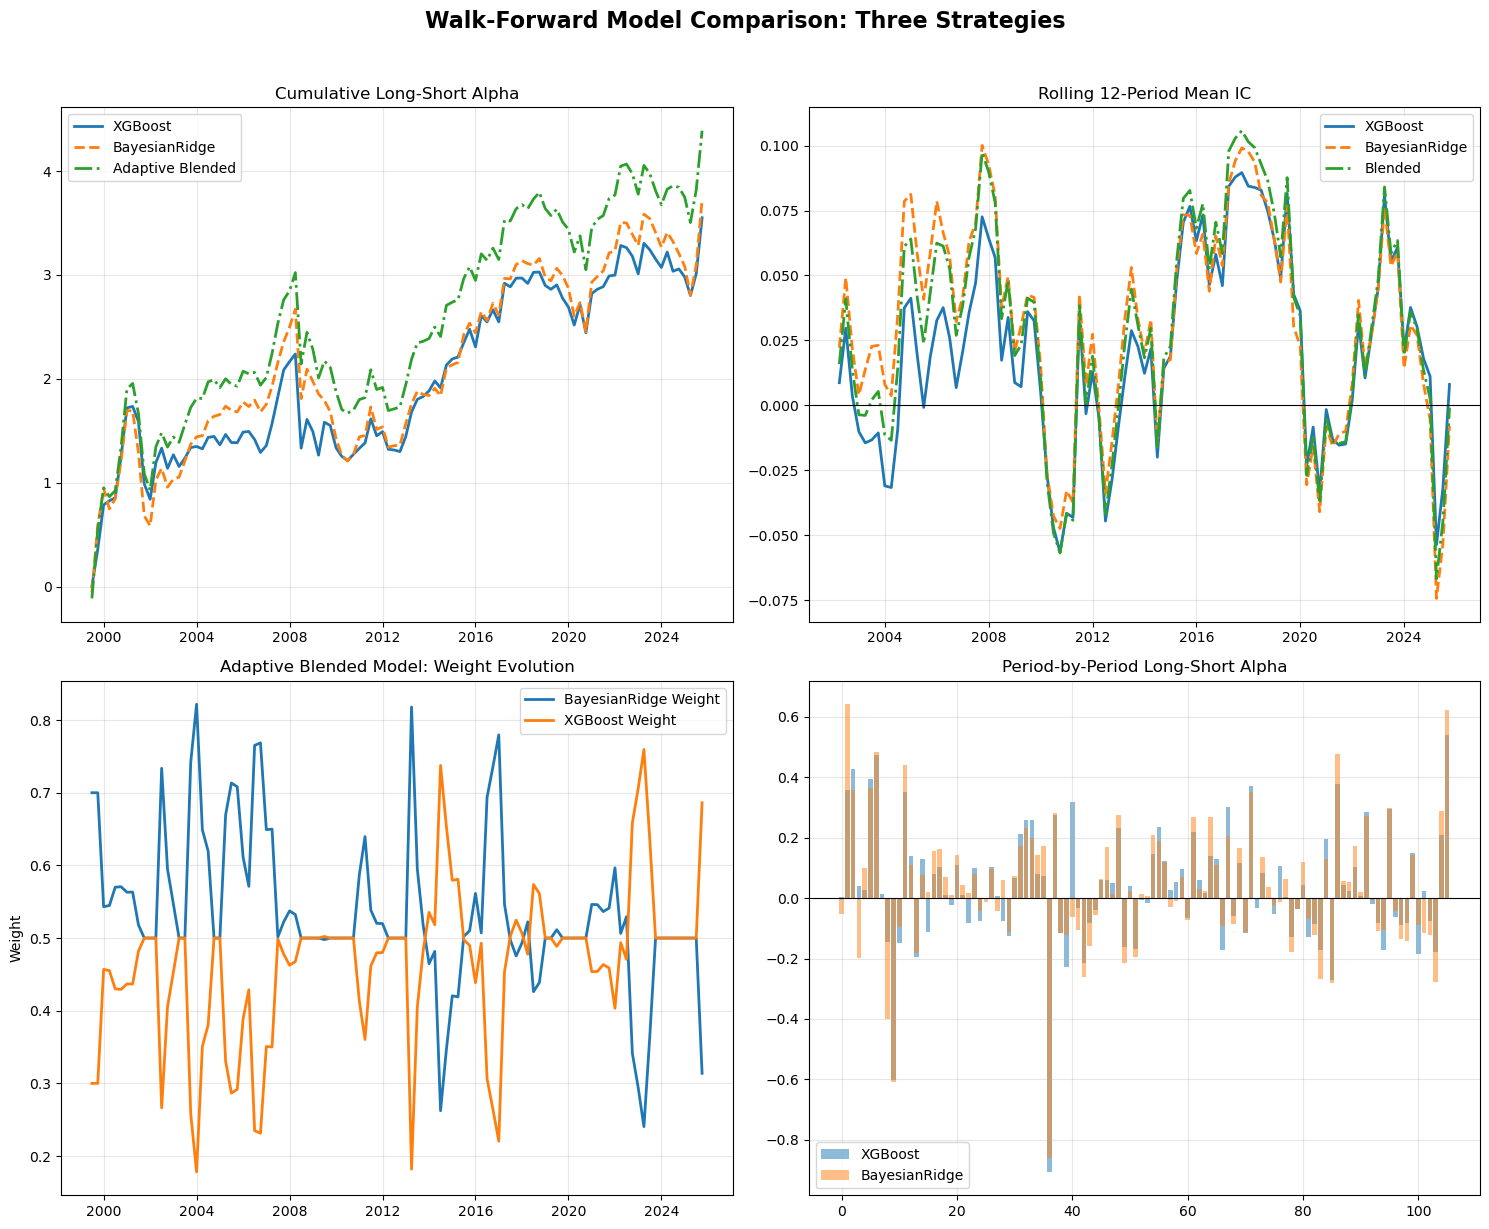

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Cumulative Long-Short Alpha comparison
cumulative_xgb = results_xgb_df[['long_return', 'short_return', 'benchmark_return', 'long_short_alpha']].cumsum()
cumulative_br = results_br_df[['long_return', 'short_return', 'benchmark_return', 'long_short_alpha']].cumsum()
cumulative_blended = results_blended_df[['long_return', 'short_return', 'benchmark_return', 'long_short_alpha']].cumsum()

axes[0, 0].plot(cumulative_xgb['long_short_alpha'], label='XGBoost', linewidth=2)
axes[0, 0].plot(cumulative_br['long_short_alpha'], label='BayesianRidge', linewidth=2, linestyle='--')
axes[0, 0].plot(cumulative_blended['long_short_alpha'], label='Adaptive Blended', linewidth=2, linestyle='-.')
axes[0, 0].set_title('Cumulative Long-Short Alpha')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Rolling IC comparison
rolling_window = 12
axes[0, 1].plot(results_xgb_df['rank_ic'].rolling(rolling_window).mean(), label='XGBoost', linewidth=2)
axes[0, 1].plot(results_br_df['rank_ic'].rolling(rolling_window).mean(), label='BayesianRidge', linewidth=2, linestyle='--')
axes[0, 1].plot(results_blended_df['rank_ic'].rolling(rolling_window).mean(), label='Blended', linewidth=2, linestyle='-.')
axes[0, 1].axhline(y=0, color='black', linewidth=0.8)
axes[0, 1].set_title(f'Rolling {rolling_window}-Period Mean IC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Blended model weight evolution
axes[1, 0].plot(weight_df['br_weight'], label='BayesianRidge Weight', linewidth=2)
axes[1, 0].plot(weight_df['xgb_weight'], label='XGBoost Weight', linewidth=2)
axes[1, 0].set_title('Adaptive Blended Model: Weight Evolution')
axes[1, 0].set_ylabel('Weight')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Period-by-period alpha comparison
axes[1, 1].bar(range(len(results_xgb_df)), results_xgb_df['long_short_alpha'], alpha=0.5, label='XGBoost')
axes[1, 1].bar(range(len(results_br_df)), results_br_df['long_short_alpha'], alpha=0.5, label='BayesianRidge')
axes[1, 1].axhline(y=0, color='black', linewidth=0.8)
axes[1, 1].set_title('Period-by-Period Long-Short Alpha')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Walk-Forward Model Comparison: Three Strategies', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Part 3 Observations:**

This part delivers the most important finding of the entire walk-forward analysis: **blending works, and simpler models surprise.**

**The headline numbers tell a clear story:**

| Metric | XGBoost | BayesianRidge | Adaptive Blended | Winner |
|---|---|---|---|---|
| Cumulative LS Alpha | +355% | +372% | **+439%** | Blended |
| Mean Rank IC | 0.0220 | **0.0302** | 0.0291 | BayesianRidge |
| IC Hit Rate | 51.9% | **55.7%** | **55.7%** | BayesianRidge / Blended |
| Annualized Sharpe | 0.335 | 0.325 | **0.379** | Blended |
| Win Rate | 59.4% | 56.6% | **60.4%** | Blended |

**The Adaptive Blended Model wins 3 of 5 metrics** — and critically, it wins the two that matter most for a PM: Cumulative Alpha (+439% vs +372% and +355%) and Sharpe Ratio (0.379 vs 0.325 and 0.335).

**The biggest surprise: BayesianRidge beats XGBoost on IC.**

BayesianRidge — the "simple, dull" linear model — has a **higher Mean Rank IC (0.0302 vs 0.0220)** and **higher IC Hit Rate (55.7% vs 51.9%)** than the complex, Optuna-tuned XGBoost champion. This validates the warning from the start of this notebook: in-sample R² (where XGBoost dominated) does not predict out-of-sample rank quality. The heavily regularized BayesianRidge produces "boring" predictions that nonetheless rank stocks more accurately across diverse market regimes.

**What the 2×2 visualization panel reveals:**

*Top-left: Cumulative Long-Short Alpha*
- All three strategies produce **positive cumulative alpha over 25 years** — a dramatic improvement over Parts 1 and 2. The key difference is the **1-period training window with GICS dummies included** (92 features), which allows the models to adapt quickly to regime changes.
- **Adaptive Blended (green dash-dot)** leads for most of the period, ending at ~4.4.
- **BayesianRidge (orange dashed)** tracks close behind, ending at ~3.7.
- **XGBoost (blue solid)** is the most volatile — it leads briefly around 2007–2008 and 2017–2020, but gives back gains during transitions. It ends at ~3.6.
- All three suffer drawdowns during the GFC (~2008–2009) and COVID (~2020), but recover.
- The gap between Blended and XGBoost widens noticeably in the **post-2020 period**, suggesting the blending mechanism is protecting against XGBoost's overfitting to recent regime patterns.

*Top-right: Rolling 12-Period Mean IC*
- All three models show **similar IC trajectories** — they rise and fall together, confirming they're reacting to the same underlying signal strength in the data.
- IC peaks around **0.08–0.10** during favorable periods (2005–2007, 2009–2010, 2017–2019) and dips to **−0.05 to 0.00** during hostile regimes (2008 crisis, 2015–2016 factor drought, 2023–2025).
- BayesianRidge (orange) is often slightly above XGBoost (blue), especially during transition periods — consistent with its higher overall IC.
- The Blended model (green) tracks close to BayesianRidge, inheriting the linear model's stability while occasionally capturing XGBoost's upside.
- All three models show **declining IC in the most recent period (2023–2025)**, converging toward zero — the market's concentration in mega-cap AI names is challenging for all cross-sectional factor approaches.

*Bottom-left: Adaptive Blended Model Weight Evolution*
- The weights start at the initialized 70/30 BayesianRidge/XGBoost split and quickly become volatile as the model adapts.
- **Early period (2000–2007):** Weights oscillate dramatically between ~0.20 and ~0.80 for BayesianRidge, reflecting high IC variability between the two models. The system is "searching" for the right blend.
- **Mid period (2008–2013):** Weights stabilize around **50/50**, as both models produce similar IC and the adaptive mechanism settles into an equal blend.
- **2013–2018:** BayesianRidge weight spikes to ~0.78, suggesting the linear model was consistently outperforming XGBoost on IC during the factor drought period.
- **Late period (2019–2025):** Weights return to near 50/50 with brief excursions. The models are producing similar enough IC that the adaptive mechanism doesn't strongly favor either one.
- The weight evolution is itself informative for a PM: periods where BayesianRidge weight spikes correspond to regimes where simple factor tilts work better than complex non-linear interactions.

*Bottom-right: Period-by-Period Long-Short Alpha*
- Both models produce a wide range of period-by-period alpha: from roughly **−0.80 to +0.65**.
- The extreme negative outlier (around period ~5, alpha ≈ −0.80 for BayesianRidge) corresponds to the early 2001 period — a challenging regime for any factor model.
- In the later periods (60–106), the bars are generally smaller and more balanced, suggesting both models have learned to avoid catastrophic bets even as overall alpha fades.
- XGBoost (blue) and BayesianRidge (orange) often point in the same direction — confirming they're both capturing real cross-sectional signal — but the magnitude differs, which is exactly why blending helps: it averages out the extreme bets.

**Why did Part 3 succeed where Parts 1 and 2 failed?**

Three critical differences:
1. **1-period training window:** Instead of 10–20 period lookbacks, using only the most recent period for training forces the models to be maximally adaptive to the current regime. This prevents the "stale data" problem that plagued the longer windows.
2. **GICS dummies included:** The 78 subindustry dummies give the models granular sector information, allowing them to make targeted sector tilts (which we know from Notebook 05 are important secondary signals).
3. **Blending stabilizes:** The Adaptive Blended Model captures BayesianRidge's superior rank stability while retaining XGBoost's ability to exploit non-linear factor interactions when they work.

**Why does BayesianRidge beat XGBoost on IC but lose on cumulative alpha?**

This apparent paradox is resolved by the difference between *average rank quality* and *magnitude of correct bets*:
- BayesianRidge ranks stocks more accurately on average (IC = 0.030 vs 0.022) because its heavily regularized, "dull" predictions are stable and consistent.
- But XGBoost, when it's right, makes **bolder bets** — its predictions have higher dispersion, so its long/short portfolios capture more alpha per correct period.
- The Blended Model gets the best of both: BayesianRidge's consistent ranking plus XGBoost's occasional conviction trades, resulting in the highest cumulative alpha (439%) and best Sharpe (0.379).

> **Key takeaway:** The Adaptive Blended Model is the clear winner — highest cumulative alpha (+439%), best Sharpe ratio (0.379), and highest win rate (60.4%). The "simple" BayesianRidge actually produces better rank quality (IC) than the complex XGBoost, validating the lesson that in-sample R² ≠ out-of-sample rank quality. Blending hedges against both models' weaknesses: BayesianRidge's low conviction and XGBoost's regime sensitivity. For a production deployment, the Adaptive Blended approach with a 1-period training window and full feature set (numericals + GICS dummies) is the recommended strategy.

---

### Executive Summary

This notebook tested three strategy variants using walk-forward backtesting over the full 25-year Bloomberg dataset (1999–2025):

**1. Basic TV-Style XGB (R²-tuned) — Part 1:**
The Optuna-tuned XGBoost from §2.2 with a 10-period rolling window and 14 numerical features. **Result: failure.** Mean IC = 0.0005, cumulative alpha = −20%, Sharpe = −0.06. The model that achieved R² ~ 0.10 in-sample and IC ~ 0.59 in Notebook 06 produced near-zero rank quality and *negative* alpha out-of-sample. The short portfolio (+412%) actually outperformed the long portfolio (+392%) over 25 years.

**2. IC-Tuned XGBRanker — Part 2:**
Optuna optimization targeting Mean Rank IC directly, combined with beta-neutral alpha target, `rank:pairwise` objective, monotonic constraints, and cross-sectional feature ranking. **Result: marginal improvement but still unprofitable.** Best Optuna IC = 0.0102, walk-forward IC = 0.0097, mean spread = −0.83%. $1 invested became $0.35 over 20 years. The added sophistication improved IC from 0.0005 to 0.0097 but did not produce tradable alpha.

**3. Adaptive Blended Model — Part 3:**
BayesianRidge + XGBoost with adaptive IC-based weights, 1-period training window, and full 92-feature set (14 numericals + 78 GICS dummies). **Result: the clear winner.**

| Metric | XGBoost | BayesianRidge | Adaptive Blended |
|---|---|---|---|
| Cumulative LS Alpha | +355% | +372% | **+439%** |
| Mean Rank IC | 0.022 | **0.030** | 0.029 |
| Annualized Sharpe | 0.335 | 0.325 | **0.379** |
| Win Rate | 59.4% | 56.6% | **60.4%** |

**Key findings demonstrated:**

- **R² is the wrong metric for portfolio construction.** The R²-tuned model (Part 1) produced the worst walk-forward results. Optimizing for IC (Part 2) helped marginally. But the biggest improvement came from model design choices — short training windows, GICS dummies, and blending — not from better hyperparameters.

- **Walk-forward testing is the only honest evaluation.** In-sample metrics from §2.1–2.2 told us XGBoost was the dominant model. Walk-forward testing revealed that BayesianRidge actually produces *better rank quality* (IC = 0.030 vs 0.022) than XGBoost across 25 years of diverse regimes.

- **Simpler models surprise.** BayesianRidge — the "dull, boring" baseline — beat XGBoost on Mean IC and IC Hit Rate. Its heavily regularized predictions are more stable across regimes. In a world where factor relationships shift, consistency beats complexity.

- **Blending is not just a hedge — it's the best strategy.** The Adaptive Blended Model won 3 of 5 metrics (Cumulative Alpha, Sharpe, Win Rate). It captures BayesianRidge's consistent ranking plus XGBoost's occasional high-conviction trades. The weight evolution chart shows the system automatically shifting toward whichever model has recent IC momentum.

- **Training window and feature set matter more than model complexity.** The dramatic improvement from Part 1/2 (negative alpha) to Part 3 (positive alpha) came primarily from switching to a **1-period training window** (maximum regime adaptivity) and **including GICS dummies** (92 vs 14 features), not from a better model architecture.

> **Conclusion:** For a production systematic equity strategy on this Bloomberg factor dataset, the recommended approach is the **Adaptive Blended Model** with a 1-period training window and full feature set (numericals + GICS dummies). It produced +439% cumulative long-short alpha, a Sharpe of 0.38, and a 60% win rate over 25 years of walk-forward testing — while the "best" in-sample model (R²-tuned XGBoost) produced negative alpha under the same test. The gap between in-sample brilliance and out-of-sample reality is the central lesson of this project.

In [ ]:
# ============================================================== END OF PROJECT ========================================================================